# PPO for Maze Editing

This notebook implements a PPO agent that learns to edit mazes by adding/removing walls to increase difficulty.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import json
import math
import pickle
from collections import deque
from torch.distributions import Categorical
import random
from torch.utils.data import DataLoader, Subset

import gc, time, math
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset

import torchvision.transforms as T

from tqdm import tqdm

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Rectangle

from IPython.display import clear_output

# Set high default resolution for figures
plt.rcParams['figure.dpi'] = 100

from bioplnn.models import (
    SpatiallyEmbeddedClassifier,
    SpatiallyEmbeddedAreaConfig,
    SpatiallyEmbeddedRNN,
    Ablation,
)
from bioplnn.datasets import Mazes
from bioplnn.utils import initialize_dataloader

# Data and checkpoint paths
maze_data_path = "/home/jackking/torch-bioplnn-dev/data/mazes"
checkpoint_path = "/home/jackking/torch-bioplnn-dev/train/checkpoints/"

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

In [ ]:
def prepare_rnn_weights(state_dict):
    """Remove 'rnn.' prefix from all keys in the state dict.
        Also remove any key starting with readout"""
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('rnn.'):
            new_key = key[4:]  # Remove 'rnn.' prefix
            new_state_dict[new_key] = value
        elif not key.startswith('readout'):
            new_state_dict[key] = value
    return new_state_dict
    
    
def load_model_and_config(wandb_name, checkpoint, full_cfg=None):
    """Load model configuration and instantiate models."""
    if full_cfg is None:
        full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))

    model_cfg = full_cfg["model_config"]

    if "num_steps" in full_cfg:
        num_steps = full_cfg["num_steps"]
    else:
        num_steps = 20
        
    print(full_cfg)
        
    if full_cfg["model_type"] == "cnn":
        model = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
        classifier = SimpleCNN(in_channels=model_cfg["in_channels"], num_classes=model_cfg["num_classes"])
    else:
        model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
        classifier = SpatiallyEmbeddedClassifier(**model_cfg)

        # ——— Load checkpoint & weights ———
    try:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
    except:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))

    try:
        state_dict = state_dict["model_state"]
    except:
        pass

    model.load_state_dict(prepare_rnn_weights(state_dict))
    classifier.load_state_dict(state_dict)

    return model, classifier, num_steps, full_cfg, state_dict

In [4]:
wandb_name, checkpoint = "dauntless-elevator-522", 390 # ReLU, with I->I recurrence

# ——— Load model config & instantiate ———
model, classifier, num_steps, cfg, state_dict = load_model_and_config(wandb_name, checkpoint)

model.eval()
model.to(device)

classifier.eval()
classifier.to(device)

{'model_type': '1e1ii1a', 'model_config': {'rnn_kwargs': {'num_areas': 1, 'area_kwargs': [{'num_neuron_types': 2, 'num_neuron_subtypes': array([8, 4]), 'neuron_type_class': array(['excitatory', 'inhibitory'], dtype='<U10'), 'inter_neuron_type_connectivity': array([[1, 1, 0],
       [1, 1, 1],
       [1, 1, 0]]), 'in_size': (48, 48), 'in_channels': 4, 'out_channels': 8, 'inter_neuron_type_nonlinearity': array([['Identity', 'Identity', 'Identity'],
       ['Identity', 'Identity', 'Identity'],
       ['Identity', 'Identity', 'Identity']], dtype='<U8'), 'inter_neuron_type_spatial_extents': (5, 5), 'neuron_type_nonlinearity': 'ReLU'}]}, 'num_classes': 2, 'fc_dim': 512, 'dropout': 0.2}, 'lr': 0.0012, 'num_steps': 20, 'max_epochs': 400, 'batch_size': 1024, 'max_gradient': 5.0, 'scheduler': {'name': 'OneCycleLR', 'kwargs': {'pct_start': 0.15, 'anneal_strategy': 'cos', 'div_factor': 20.0}}, 'init_weights': 'none', 'seed': 4, 'dots_kwargs': {}}


/tmp/ipykernel_2483842/4283728039.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_locati

SpatiallyEmbeddedClassifier(
  (rnn): SpatiallyEmbeddedRNN(
    (areas): ModuleList(
      (0): SpatiallyEmbeddedArea(
        (out_nonlinearity): Identity()
        (neuron_type_nonlinearity): ModuleList(
          (0-1): 2 x ReLU()
        )
        (convs): ModuleDict(
          (0->0): Sequential(
            (0): Conv2d(4, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): Identity()
          )
          (0->1): Sequential(
            (0): Conv2d(4, 4, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): Identity()
          )
          (1->0): Sequential(
            (0): Conv2dRectify(8, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): Identity()
          )
          (1->1): Sequential(
            (0): Conv2dRectify(8, 4, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): Identity()
          )
          (2->0): Sequential(
            (0): Conv2dRectify(4, 8, kernel_size=(5, 5), stride=(1, 1), padding

In [21]:
from functools import partial

def entropy_reward(mazes, negative_reward=False, num_steps=15):
    """
    Computes reward for given maze state(s).
    
    Args:
        mazes: torch.Tensor of shape [2, 24, 24] for single maze
               OR [batch_size, 2, 24, 24] for batched mazes
               mazes[..., 0, :, :] = walls (1 = wall, 0 = open)
               mazes[..., 1, :, :] = start/end points (1 = point, 0 = empty)
        negative_reward: If True, return negative entropy (to turn reward into penalty).
    
    Returns:
        float or torch.Tensor: Reward value(s) (higher = more difficult maze)
                               Single float for single maze, tensor [batch_size] for batched
    """
    if mazes.dim() == 3:
        mazes = mazes.unsqueeze(0)
    
    # Upsample by a factor of 2 using nearest neighbor interpolation
    maze_upsampled = F.interpolate(mazes.float(), scale_factor=2, mode='nearest')

    # Add a border 3 cells wide (using torch's pad)
    maze_with_border = F.pad(maze_upsampled, (3, 3, 3, 3), mode='constant', value=0)

    # Repeat the first channel two more times, then stack the last channel
    first_channel = maze_with_border[:, 0:1, :, :]  # shape: (batch, 1, H, W)
    # Repeat to get (batch, 3, H, W)
    first_channel_repeated = first_channel.repeat(1, 3, 1, 1)
    last_channel = maze_with_border[:, -1:, :, :]   # shape: (batch, 1, H, W)

    # Stack the repeated first channel and the last channel along dim=1
    maze_processed = torch.cat([first_channel_repeated, last_channel], dim=1).to(device)

    logits = classifier(maze_processed, num_steps=num_steps)
    print(np.argmax(logits.detach().cpu().numpy(), axis=1))
    entropy = torch.distributions.Categorical(logits=logits).entropy().detach().cpu()
    if negative_reward:
        entropy = -entropy
    return entropy

def get_reward_fn(reward_fn=entropy_reward, negative_reward=False, num_steps=15):
    return partial(reward_fn, negative_reward=negative_reward, num_steps=num_steps)

In [6]:
# Maze Editing Environment
class MazeEditEnv:
    """
    Environment for editing mazes.
    
    State: [2, 24, 24] tensor (channel 0: walls, channel 1: start/end points)
    Actions: 0-575 (add wall at position), 576-1151 (remove wall), 1152 (END)
    """
    def __init__(self, reward_fn, grid_size=24, step_penalty=-0.01, max_steps=50, dense_reward=True, end_bonus=0.0, end_token=True):
        self.reward_fn = reward_fn
        self.step_penalty = step_penalty
        self.max_steps = max_steps
        self.dense_reward = dense_reward  # If True, evaluate reward_fn at every step
        self.end_bonus = end_bonus  # Bonus reward for calling END (encourages early stopping)
        self.maze = None
        self.start_end_positions = None
        self.steps = 0
        self.grid_size = grid_size
        self.add_cutoff = self.grid_size * self.grid_size
        self.action_dim = grid_size * grid_size * 2 + 1  # 2 actions per cell (add/remove) + 1 END/SKIP action
        if end_token:
            self.end_action = self.action_dim - 1
            self.skip_action = None
        else:
            self.skip_action = self.action_dim - 1
            self.end_action = None
        
        
    def reset(self, initial_maze=None):
        """
        Reset environment to initial state.
        
        Args:
            initial_maze: Optional [2, self.grid_size, self.grid_size] tensor. If None, creates random maze.
        
        Returns:
            obs: [2, self.grid_size, self.grid_size] tensor
            action_mask: [self.action_dim] boolean tensor
        """
        if initial_maze is None:
            # Create random starting maze
            self.maze = torch.zeros(2, self.grid_size, self.grid_size)
            # Add random walls (30% density)
            self.maze[0] = (torch.rand(self.grid_size, self.grid_size) < 0.3).float()
            # Add start and end points
            self.maze[1, 0, 0] = 1  # Start
            self.maze[1, self.grid_size-1, self.grid_size-1] = 1  # End
            # Ensure start/end don't have walls
            self.maze[0, 0, 0] = 0
            self.maze[0, self.grid_size-1, self.grid_size-1] = 0
        else:
            self.maze = initial_maze.clone()
        
        # Store start/end positions for action masking
        self.start_end_positions = (self.maze[1] == 1).nonzero(as_tuple=False)
        self.steps = 0
        
        return self.maze.clone(), self._get_action_mask()
    
    def _get_action_mask(self):
        """
        Generate mask of valid actions.
        
        Returns:
            mask: [1153] tensor where 1 = valid action, 0 = invalid
        """
        mask = torch.ones(self.action_dim)
        
        # Disable adding walls on start/end positions
        for pos in self.start_end_positions:
            row, col = pos[0].item(), pos[1].item()
            action_idx = row * self.grid_size + col
            mask[action_idx] = 0
        
        # Disable removing walls where no wall exists
        for row in range(self.grid_size):
            for col in range(self.grid_size):
                if self.maze[0, row, col] == 1:
                    action_idx = self.grid_size * self.grid_size + row * self.grid_size + col
                    mask[action_idx] = 0
        
        # Disable adding walls where there is already a wall
        for row in range(self.grid_size):
            for col in range(self.grid_size):
                if self.maze[0, row, col] == 0:
                    action_idx = row * self.grid_size + col
                    mask[action_idx] = 0
        
        # END action is always valid
        return mask
    
    def step(self, action):
        """
        Execute action in environment.
        
        Args:
            action: int in [0, 1152]
        
        Returns:
            next_obs: [2, 24, 24] tensor
            reward: float
            done: bool
            next_mask: [1153] tensor
        """
        self.steps += 1
        is_end = False
        
        if action == self.end_action: 
            done = True
            is_end = True
        else:
            # Apply wall edit
            if action == self.skip_action:
                pass
            elif action < self.add_cutoff:  # Add wall
                row, col = action // self.grid_size, action % self.grid_size
                self.maze[0, row, col] = 0
            else:  
                action_offset = action - self.add_cutoff
                row, col = action_offset // self.grid_size, action_offset % self.grid_size
                self.maze[0, row, col] = 1
            
            done = self.steps >= self.max_steps

        next_mask = self._get_action_mask()
        return self.maze.clone(), done, is_end, next_mask
    
    def render(self):
        """Visualize current maze state."""
        plt.figure(figsize=(6, 6))
        # Walls=1, start/end=2, empty=0
        display = self.maze[0].numpy() + 2 * self.maze[1].numpy()
        plt.imshow(display, cmap='viridis')
        plt.colorbar(label='0=empty, 1=wall, 2=start/end')
        plt.title(f'Step {self.steps}')
        plt.show()

In [7]:
# Actor-Critic Policy Network
class ActorCritic(nn.Module):
    """
    Policy network with shared CNN backbone and separate actor/critic heads.
    Handles action masking in the forward pass.
    """
    def __init__(self, obs_channels=2, hidden_dim=128, action_dim=1153):
        super().__init__()
        
        # Shared CNN backbone
        self.backbone = nn.Sequential(
            nn.Conv2d(obs_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 24 -> 12
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1),  # 12 -> 6
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)  # -> [B, 64, 1, 1]
        )
        
        # Policy head (actor)
        self.policy_head = nn.Sequential(
            nn.Linear(64, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )
        
        # Value head (critic)
        self.value_head = nn.Sequential(
            nn.Linear(64, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, obs, action_mask=None):
        """
        Forward pass with action masking.
        
        Args:
            obs: [B, 2, 24, 24] tensor
            action_mask: [B, 1153] tensor (1=valid, 0=invalid)
        
        Returns:
            logits: [B, 1153] tensor (masked)
            value: [B, 1] tensor
        """
        # Extract features
        features = self.backbone(obs)
        features = features.squeeze(-1).squeeze(-1)  # [B, 64]
        
        # Compute logits
        logits = self.policy_head(features)
        
        # CRITICAL: Apply action masking before creating distribution
        if action_mask is not None:
            logits = logits.masked_fill(action_mask == 0, -1e8)
        
        # Compute value
        value = self.value_head(features)
        
        return logits, value

In [8]:
# Rollout Buffer
class RolloutBuffer:
    """
    Stores trajectories for PPO updates.
    Stores data on CPU to avoid memory issues.
    """
    def __init__(self):
        self.observations = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.values = []
        self.dones = []
        self.action_masks = []
    
    def add(self, obs, action, log_prob, reward, value, done, action_mask):
        """Add single timestep to buffer."""
        self.observations.append(obs.cpu())
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.values.append(value)
        self.dones.append(float(done))
        self.action_masks.append(action_mask.cpu())
    
    def get_batch(self):
        """Convert lists to tensors for batch processing."""
        return {
            'obs': torch.stack(self.observations),
            'actions': torch.tensor(self.actions, dtype=torch.long),
            'log_probs': torch.tensor(self.log_probs, dtype=torch.float32),
            'rewards': torch.tensor(self.rewards, dtype=torch.float32),
            'values': torch.tensor(self.values, dtype=torch.float32),
            'dones': torch.tensor(self.dones, dtype=torch.float32),
            'action_masks': torch.stack(self.action_masks)
        }
    
    def clear(self):
        """Clear buffer."""
        self.__init__()
    
    def __len__(self):
        return len(self.observations)

In [9]:
# GAE (Generalized Advantage Estimation)
def compute_gae(rewards, values, dones, next_value, gamma=0.99, gae_lambda=0.95):
    """
    Compute advantages using Generalized Advantage Estimation.
    
    Args:
        rewards: [T] tensor of rewards
        values: [T] tensor of value estimates
        dones: [T] tensor of done flags
        next_value: scalar, value of state after last step
        gamma: discount factor
        gae_lambda: GAE lambda parameter
    
    Returns:
        advantages: [T] tensor
        returns: [T] tensor
    """
    advantages = torch.zeros_like(rewards)
    gae = 0
    
    # Work backwards through trajectory
    for t in reversed(range(len(rewards))):
        if t == len(rewards) - 1:
            next_val = next_value
            next_done = dones[t]
        else:
            next_val = values[t + 1]
            next_done = dones[t + 1]
        
        # TD error: δ_t = r_t + γ V(s_{t+1}) - V(s_t)
        delta = rewards[t] + gamma * next_val * (1 - next_done) - values[t]
        
        # GAE: A_t = δ_t + (γλ) δ_{t+1} + (γλ)² δ_{t+2} + ...
        gae = delta + gamma * gae_lambda * (1 - next_done) * gae
        advantages[t] = gae
    
    # Returns are advantages + values
    returns = advantages + values
    
    return advantages, returns

# PPO Loss Function
def compute_ppo_loss(
    policy_net,
    obs_batch,
    action_batch,
    old_log_probs_batch,
    advantages_batch,
    returns_batch,
    action_masks_batch,
    clip_epsilon=0.2,
    value_coef=0.5,
    entropy_coef=0.01
):
    """
    Compute PPO clipped objective loss.
    
    Returns:
        total_loss: scalar tensor
        metrics: dict of training metrics
    """
    # Forward pass with action masking
    logits, values = policy_net(obs_batch, action_masks_batch)
    values = values.squeeze(-1)
    
    # Get log probs for actions taken
    dist = Categorical(logits=logits)
    log_probs = dist.log_prob(action_batch)
    entropy = dist.entropy()
    
    # Normalize advantages (CRITICAL for stable training)
    advantages_batch = (advantages_batch - advantages_batch.mean()) / (advantages_batch.std() + 1e-8)
    
    # PPO clipped objective
    ratio = torch.exp(log_probs - old_log_probs_batch)
    surr1 = ratio * advantages_batch
    surr2 = torch.clamp(ratio, 1 - clip_epsilon, 1 + clip_epsilon) * advantages_batch
    policy_loss = -torch.min(surr1, surr2).mean()
    
    # Value loss
    value_loss = 0.5 * (values - returns_batch).pow(2).mean()
    
    # Entropy bonus (encourage exploration)
    entropy_loss = -entropy.mean()
    
    # Combined loss
    total_loss = policy_loss + value_coef * value_loss + entropy_coef * entropy_loss
    
    # Metrics for logging
    metrics = {
        'policy_loss': policy_loss.item(),
        'value_loss': value_loss.item(),
        'entropy': -entropy_loss.item(),
        'approx_kl': ((ratio - 1) - log_probs + old_log_probs_batch).mean().item()
    }
    
    return total_loss, metrics

In [10]:
# Main PPO Training Loop with Batched Rollouts and Batched Reward Computation
def train_ppo(
    env,
    policy_net,
    num_iterations=1000,
    num_parallel_envs=32,
    steps_per_env=64,
    num_epochs=10,
    minibatch_size=64,
    lr=3e-4,
    gamma=0.99,
    gae_lambda=0.95,
    clip_epsilon=0.2,
    value_coef=0.5,
    entropy_coef=0.01,
    max_grad_norm=0.5,
    device='cuda',
    maze_loader=None
):
    """
    Train PPO agent with batched rollout collection and batched reward computation.
    
    Args:
        env: MazeEditEnv instance (used as template to create parallel copies)
        policy_net: ActorCritic network
        num_iterations: Number of training iterations
        num_parallel_envs: Number of parallel environments (batch size during rollout)
        steps_per_env: Steps per environment (total rollout = num_parallel_envs * steps_per_env)
        num_epochs: Number of update epochs per iteration
        minibatch_size: Minibatch size for updates
        lr: Learning rate
        Other args: PPO hyperparameters
    
    Returns:
        training_metrics: dict with training history
        timing_stats: dict with timing breakdowns
    """
    import time
    import copy
    
    optimizer = torch.optim.Adam(policy_net.parameters(), lr=lr)
    policy_net.to(device)
    policy_net.train()
    
    # Create separate environment instances for each parallel slot
    envs = [copy.deepcopy(env) for _ in range(num_parallel_envs)]
    
    # Tracking metrics
    training_metrics = {
        'iteration': [],
        'avg_return': [],
        'avg_episode_length': [],
        'policy_loss': [],
        'value_loss': [],
        'entropy': [],
        'approx_kl': []
    }
    
    # Timing metrics
    timing_stats = {
        'rollout': [],
        'reward_computation': [],
        'gae': [],
        'update': [],
        'total': []
    }
    
    rollout_length = num_parallel_envs * steps_per_env
    iterator = iter(maze_loader)
    
    for iteration in tqdm(range(num_iterations), desc='Training PPO'):
        iter_start = time.time()
        
        # === Phase 1: Collect Rollouts (BATCHED) ===
        rollout_start = time.time()
        
        # Store trajectories per environment (cleaner indexing)
        env_trajectories = [[] for _ in range(num_parallel_envs)]

        # Get mazes
        mazes = next(iterator)[0]
        walls = mazes[:, 0, :, :]
        starts = mazes[:, -1, :, :]
        mazes = torch.stack([walls, starts], dim=1)
        mazes = mazes[:, :, ::2, ::2]
        mazes = mazes[:, :, 2:-1, 2:-1]
                
        # Initialize parallel environments (each has its own maze)
        obs_batch = []
        mask_batch = []
        for i in range(num_parallel_envs):
            obs, mask = envs[i].reset(mazes[i])
            obs_batch.append(obs)
            mask_batch.append(mask)
        
        obs_batch = torch.stack(obs_batch)  # [N, 2, 24, 24]
        mask_batch = torch.stack(mask_batch)  # [N, 1153]
        
        # Track episode stats
        episode_returns = []
        episode_lengths = []
        current_returns = torch.zeros(num_parallel_envs)
        current_lengths = torch.zeros(num_parallel_envs)
        episode_done = torch.zeros(num_parallel_envs, dtype=torch.bool)
        
        for step in range(steps_per_env):
            # Batched forward pass
            obs_tensor = obs_batch.to(device)
            mask_tensor = mask_batch.to(device)
            
            with torch.no_grad():
                logits, values = policy_net(obs_tensor, mask_tensor)
                dist = Categorical(logits=logits)
                actions = dist.sample()
                log_probs = dist.log_prob(actions)
            
            # Step all environments (without computing rewards yet)
            next_obs_batch = []
            next_mask_batch = []
            maze_states = []  # Collect maze states for batched reward computation
            is_end_actions = []
            dones = []
            
            for i in range(num_parallel_envs):
                if not episode_done[i]:
                    # Step the specific environment (no reward computed here)
                    next_obs, done, is_end, next_mask = envs[i].step(actions[i].item())
                    maze_states.append(envs[i].maze.clone())
                    is_end_actions.append(is_end)
                    dones.append(done)
                else:
                    # Episode already finished, pad with dummy data
                    next_obs = obs_batch[i]
                    next_mask = mask_batch[i]
                    maze_states.append(envs[i].maze.clone())
                    is_end_actions.append(False)
                    dones.append(True)
                
                next_obs_batch.append(next_obs)
                next_mask_batch.append(next_mask)
            
            # === BATCHED REWARD COMPUTATION ===
            reward_start = time.time()
            maze_states_tensor = torch.stack(maze_states)  # [N, 2, 24, 24]
            
            if env.dense_reward:
                # Dense: evaluate all mazes
                batched_rewards = env.reward_fn(maze_states_tensor)
            else:
                # Sparse: only evaluate mazes that are ending (END action or timeout)
                needs_eval = [is_end_actions[i] or (dones[i] and not episode_done[i]) 
                            for i in range(num_parallel_envs)]
                
                if any(needs_eval):
                    eval_indices = [i for i, need in enumerate(needs_eval) if need]
                    eval_mazes = torch.stack([maze_states[i] for i in eval_indices])
                    eval_rewards = env.reward_fn(eval_mazes)
                    
                    batched_rewards = np.zeros(num_parallel_envs)
                    for idx, i in enumerate(eval_indices):
                        batched_rewards[i] = eval_rewards[idx]
                else:
                    batched_rewards = np.zeros(num_parallel_envs)

            reward_time = time.time() - reward_start
            if step == 0:  # Track only first step timing
                timing_stats.setdefault('reward_computation', []).append(reward_time)
            
            # Assign rewards with bonuses and penalties
            for i in range(num_parallel_envs):
                if not episode_done[i]:
                    if is_end_actions[i]:
                        # END action: final reward + bonus
                        reward = batched_rewards[i] + env.end_bonus
                    elif dones[i] and not env.dense_reward:
                        # Timeout without END in sparse mode: still evaluate final maze
                        reward = batched_rewards[i] + env.step_penalty
                    else:
                        # Regular step
                        if env.dense_reward:
                            reward = batched_rewards[i] + env.step_penalty
                        else:
                            reward = env.step_penalty
                    
                    current_returns[i] += reward
                    current_lengths[i] += 1
                    
                    # Store transition
                    env_trajectories[i].append({
                        'obs': obs_batch[i].cpu(),
                        'action': actions[i].item(),
                        'log_prob': log_probs[i].item(),
                        'reward': reward,
                        'value': values[i].item(),
                        'done': dones[i],
                        'mask': mask_batch[i].cpu()
                    })
                    
                    if dones[i]:
                        episode_done[i] = True
                        episode_returns.append(current_returns[i].item())
                        episode_lengths.append(current_lengths[i].item())
                        current_returns[i] = 0
                        current_lengths[i] = 0
                        # Reset environment
                        next_obs_batch[i], next_mask_batch[i] = envs[i].reset()

                elif episode_done[i]:
                    # Already done, just pad
                    env_trajectories[i].append({
                        'obs': obs_batch[i].cpu(),
                        'action': actions[i].item(),
                        'log_prob': log_probs[i].item(),
                        'reward': 0.0,
                        'value': values[i].item(),
                        'done': True,
                        'mask': mask_batch[i].cpu()
                    })

            obs_batch = torch.stack(next_obs_batch)
            mask_batch = torch.stack(next_mask_batch)
        
        rollout_time = time.time() - rollout_start
        
        # === Phase 2: Compute Advantages ===
        gae_start = time.time()
        
        # Bootstrap value for last states
        with torch.no_grad():
            _, next_values = policy_net(
                obs_batch.to(device),
                mask_batch.to(device)
            )
        
        # Compute GAE for each trajectory and flatten into single buffer
        all_obs = []
        all_actions = []
        all_log_probs = []
        all_rewards = []
        all_values = []
        all_dones = []
        all_masks = []
        all_advantages = []
        all_returns = []
        
        for i in range(num_parallel_envs):
            # Extract trajectory for environment i (now contiguous!)
            traj = env_trajectories[i]
            traj_rewards = torch.tensor([t['reward'] for t in traj], dtype=torch.float32)
            traj_values = torch.tensor([t['value'] for t in traj], dtype=torch.float32)
            traj_dones = torch.tensor([t['done'] for t in traj], dtype=torch.float32)
            
            # Compute advantages for this trajectory
            advantages, returns = compute_gae(
                traj_rewards,
                traj_values,
                traj_dones,
                next_values[i].item(),
                gamma=gamma,
                gae_lambda=gae_lambda
            )
            
            # Add to flattened buffer
            for j, t in enumerate(traj):
                all_obs.append(t['obs'])
                all_actions.append(t['action'])
                all_log_probs.append(t['log_prob'])
                all_rewards.append(t['reward'])
                all_values.append(t['value'])
                all_dones.append(t['done'])
                all_masks.append(t['mask'])
                all_advantages.append(advantages[j].item())
                all_returns.append(returns[j].item())
        
        # Convert to tensors
        batch = {
            'obs': torch.stack(all_obs),
            'actions': torch.tensor(all_actions, dtype=torch.long),
            'log_probs': torch.tensor(all_log_probs, dtype=torch.float32),
            'rewards': torch.tensor(all_rewards, dtype=torch.float32),
            'values': torch.tensor(all_values, dtype=torch.float32),
            'dones': torch.tensor(all_dones, dtype=torch.float32),
            'action_masks': torch.stack(all_masks)
        }
        advantages = torch.tensor(all_advantages, dtype=torch.float32)
        returns = torch.tensor(all_returns, dtype=torch.float32)
        
        gae_time = time.time() - gae_start
        
        # === Phase 3: Policy Update (K epochs) ===
        update_start = time.time()
        dataset_size = len(all_obs)
        
        epoch_metrics = {'policy_loss': [], 'value_loss': [], 'entropy': [], 'approx_kl': []}
        
        for epoch in range(num_epochs):
            # Shuffle data
            indices = torch.randperm(dataset_size)
            
            for start_idx in range(0, dataset_size, minibatch_size):
                end_idx = min(start_idx + minibatch_size, dataset_size)
                mb_indices = indices[start_idx:end_idx]
                
                # Prepare minibatch
                mb_obs = batch['obs'][mb_indices].to(device)
                mb_actions = batch['actions'][mb_indices].to(device)
                mb_old_log_probs = batch['log_probs'][mb_indices].to(device)
                mb_advantages = advantages[mb_indices].to(device)
                mb_returns = returns[mb_indices].to(device)
                mb_masks = batch['action_masks'][mb_indices].to(device)
                
                # Compute loss and update
                loss, metrics = compute_ppo_loss(
                    policy_net,
                    mb_obs,
                    mb_actions,
                    mb_old_log_probs,
                    mb_advantages,
                    mb_returns,
                    mb_masks,
                    clip_epsilon=clip_epsilon,
                    value_coef=value_coef,
                    entropy_coef=entropy_coef
                )
                
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_grad_norm)
                optimizer.step()
                
                # Track metrics
                for key in metrics:
                    epoch_metrics[key].append(metrics[key])
        
        update_time = time.time() - update_start
        total_time = time.time() - iter_start
        
        # === Phase 4: Logging ===
        avg_return = np.mean(episode_returns) if episode_returns else 0
        avg_length = np.mean(episode_lengths) if episode_lengths else 0
        
        training_metrics['iteration'].append(iteration)
        training_metrics['avg_return'].append(avg_return)
        training_metrics['avg_episode_length'].append(avg_length)
        training_metrics['policy_loss'].append(np.mean(epoch_metrics['policy_loss']))
        training_metrics['value_loss'].append(np.mean(epoch_metrics['value_loss']))
        training_metrics['entropy'].append(np.mean(epoch_metrics['entropy']))
        training_metrics['approx_kl'].append(np.mean(epoch_metrics['approx_kl']))
        
        # Track timing
        timing_stats['rollout'].append(rollout_time)
        timing_stats['gae'].append(gae_time)
        timing_stats['update'].append(update_time)
        timing_stats['total'].append(total_time)
        
        if iteration % 1 == 0:
            print(f"\nIter {iteration} | Episodes: {len(episode_returns)} | Return: {avg_return:.2f} | Len: {avg_length:.1f}")
            print(f"  Policy Loss: {training_metrics['policy_loss'][-1]:.4f} | Entropy: {training_metrics['entropy'][-1]:.4f}")
            print(f"  Time - Rollout: {rollout_time:.2f}s | GAE: {gae_time:.3f}s | Update: {update_time:.2f}s | Total: {total_time:.2f}s")
    
    # Print timing summary
    print("\n" + "="*60)
    print("TIMING SUMMARY (averaged over all iterations)")
    print("="*60)
    print(f"Rollout collection:  {np.mean(timing_stats['rollout']):.3f}s  ({np.mean(timing_stats['rollout'])/np.mean(timing_stats['total'])*100:.1f}%)")
    print(f"GAE computation:     {np.mean(timing_stats['gae']):.3f}s  ({np.mean(timing_stats['gae'])/np.mean(timing_stats['total'])*100:.1f}%)")
    print(f"Policy updates:      {np.mean(timing_stats['update']):.3f}s  ({np.mean(timing_stats['update'])/np.mean(timing_stats['total'])*100:.1f}%)")
    print(f"Total per iteration: {np.mean(timing_stats['total']):.3f}s")
    print(f"Estimated total:     {np.sum(timing_stats['total'])/60:.1f} minutes")
    print("="*60)
    
    return training_metrics, timing_stats

In [17]:
hyperparams = {
    "env_params": {
        "grid_size": 21,
        "max_steps": 5,
        "end_token": False,
        "step_penalty": 0,
        "dense_reward": True,
        "end_bonus": 0,
        "model_steps": 20
    },
    "policy_params": {
        "hidden_dim": 256,
    },
    "training_params": {
        "lr": 2e-5,
        "batch_size": 1024,
        "num_epochs": 5,
        "minibatch_size": 256,
        "num_iterations": 100,
        "gamma": 0.99,
        "gae_lambda": 0.97,
        "clip_epsilon": 0.2,
        "value_coef": 0.8,
        "entropy_coef": 0.0005,
        "max_grad_norm": 0.5
    }
}
    

In [18]:
reward_fn = get_reward_fn(entropy_reward, negative_reward=False, num_steps=hyperparams["env_params"]["model_steps"])
env = MazeEditEnv(
    reward_fn=reward_fn, 
    step_penalty=hyperparams["env_params"]["step_penalty"],      # Small penalty per step to encourage efficiency
    max_steps=hyperparams["env_params"]["max_steps"],            # Maximum edits per episode
    dense_reward=hyperparams["env_params"]["dense_reward"],       # Give reward feedback at every step (not just END)
    end_bonus=hyperparams["env_params"]["end_bonus"],            # Small bonus for calling END (encourages learning to stop)
    grid_size=hyperparams["env_params"]["grid_size"],
    end_token=hyperparams["env_params"]["end_token"]
)
policy = ActorCritic(obs_channels=2, hidden_dim=hyperparams["policy_params"]["hidden_dim"], action_dim=env.action_dim)

print(f"Policy network parameters: {sum(p.numel() for p in policy.parameters()):,}")
print(f"Device: {device}")
print(f"\nReward structure:")
print(f"  - Dense reward: {env.dense_reward} (agent gets reward_fn feedback every step)")
print(f"  - Step penalty: {env.step_penalty} (encourages fewer edits)")
print(f"  - END bonus: {env.end_bonus} (encourages learning to stop)")
print(f"  - Max steps: {env.max_steps}")

Policy network parameters: 316,500
Device: cuda

Reward structure:
  - Dense reward: True (agent gets reward_fn feedback every step)
  - Step penalty: 0 (encourages fewer edits)
  - END bonus: 0 (encourages learning to stop)
  - Max steps: 5


In [13]:

# iterator = iter(maze_loader)
# maze = next(iterator)[0]
# print(maze.shape)
# walls = maze[:, 0, :, :]
# starts = maze[:, -1, :, :]
# maze = torch.stack([walls, starts], dim=1)
# print(maze.shape)
# plt.imshow(maze[0, 1].numpy())
# plt.show()
# maze = maze[:, :, ::2, ::2]
# print(maze.shape)
# plt.imshow(maze[0, 1].numpy())
# plt.show()
# maze = maze[:, :, 2:-1, 2:-1]
# print(maze.shape)
# plt.imshow(maze[0, 1].numpy())
# plt.show()
# print(maze.shape)



# # Upsample by a factor of 2 using nearest neighbor interpolation
# maze_upsampled = F.interpolate(maze.float(), scale_factor=2, mode='nearest')

# # Add a border 3 cells wide (using torch's pad)
# maze_with_border = F.pad(maze_upsampled, (3, 3, 3, 3), mode='constant', value=0)
# print(maze_with_border.shape)
# plt.imshow(maze_with_border[0, 1].numpy())

# # Repeat the first channel two more times, then stack the last channel
# first_channel = maze_with_border[:, 0:1, :, :]  # shape: (batch, 1, H, W)
# # Repeat to get (batch, 3, H, W)
# first_channel_repeated = first_channel.repeat(1, 3, 1, 1)
# last_channel = maze_with_border[:, -1:, :, :]   # shape: (batch, 1, H, W)

# # Stack the repeated first channel and the last channel along dim=1
# maze_processed = torch.cat([first_channel_repeated, last_channel], dim=1)
# print(maze_processed.shape)
# plt.imshow(maze_processed[0, 3].numpy())  # display first of repeated channels


# plt.show()


In [ ]:
# Train the agent with batched rollouts
# Total rollout size = num_parallel_envs * steps_per_env

batch_size = hyperparams["training_params"]["batch_size"]
maze_loader, test_loader = initialize_dataloader(
    seed=42, root=maze_data_path, batch_size=batch_size, dataset="mazes",
)

#TRY NEGATIVE

# Create a loader with only the positive examples from maze_loader
maze_dataset = maze_loader.dataset
positive_indices = [i for i, sample in enumerate(maze_dataset)
                    if hasattr(sample, "__getitem__") and len(sample) > 1 and sample[1] == 0]

# # If dataset returns only (data, label) as a tuple
# if not positive_indices and hasattr(maze_dataset, 'targets'):
#     positive_indices = [i for i, label in enumerate(maze_dataset.targets) if label == 1]

positive_maze_dataset = Subset(maze_dataset, positive_indices)
maze_loader = DataLoader(positive_maze_dataset, batch_size=batch_size, shuffle=True)

metrics, timing_stats = train_ppo(
    env=env,
    policy_net=policy,
    num_iterations=hyperparams["training_params"]["num_iterations"],
    num_parallel_envs=batch_size,     # Batch size during rollout
    steps_per_env=hyperparams["env_params"]["max_steps"],         # Steps per environment
    num_epochs=hyperparams["training_params"]["num_epochs"],
    minibatch_size=hyperparams["training_params"]["minibatch_size"],
    lr=hyperparams["training_params"]["lr"],
    gamma=hyperparams["training_params"]["gamma"],
    gae_lambda=hyperparams["training_params"]["gae_lambda"],
    clip_epsilon=hyperparams["training_params"]["clip_epsilon"],
    value_coef=hyperparams["training_params"]["value_coef"],
    entropy_coef=hyperparams["training_params"]["entropy_coef"],
    max_grad_norm=hyperparams["training_params"]["max_grad_norm"],
    device=device,
    maze_loader=maze_loader,
)

Training PPO:   1%|          | 1/100 [01:01<1:41:58, 61.80s/it]


Iter 0 | Episodes: 1024 | Return: 0.06 | Len: 5.0
  Policy Loss: -0.0009 | Entropy: 6.0857
  Time - Rollout: 60.95s | GAE: 0.280s | Update: 0.58s | Total: 61.80s


Training PPO:   2%|▏         | 2/100 [02:03<1:40:29, 61.52s/it]


Iter 1 | Episodes: 1024 | Return: 0.05 | Len: 5.0
  Policy Loss: -0.0009 | Entropy: 6.0856
  Time - Rollout: 60.59s | GAE: 0.280s | Update: 0.45s | Total: 61.32s


Training PPO:   3%|▎         | 3/100 [03:04<1:39:22, 61.47s/it]

...


Iter 97 | Episodes: 1024 | Return: 0.12 | Len: 5.0
  Policy Loss: -0.0034 | Entropy: 0.9871
  Time - Rollout: 60.86s | GAE: 0.284s | Update: 0.45s | Total: 61.60s


Training PPO:  99%|█████████▉| 99/100 [1:41:41<01:01, 61.66s/it]


Iter 98 | Episodes: 1024 | Return: 0.14 | Len: 5.0
  Policy Loss: -0.0024 | Entropy: 0.9319
  Time - Rollout: 60.91s | GAE: 0.285s | Update: 0.45s | Total: 61.64s


Training PPO: 100%|██████████| 100/100 [1:42:43<00:00, 61.63s/it]


Iter 99 | Episodes: 1024 | Return: 0.13 | Len: 5.0
  Policy Loss: -0.0020 | Entropy: 0.8939
  Time - Rollout: 60.98s | GAE: 0.277s | Update: 0.45s | Total: 61.71s

TIMING SUMMARY (averaged over all iterations)
Rollout collection:  60.896s  (98.8%)
GAE computation:     0.281s  (0.5%)
Policy updates:      0.455s  (0.7%)
Total per iteration: 61.632s
Estimated total:     102.7 minutes


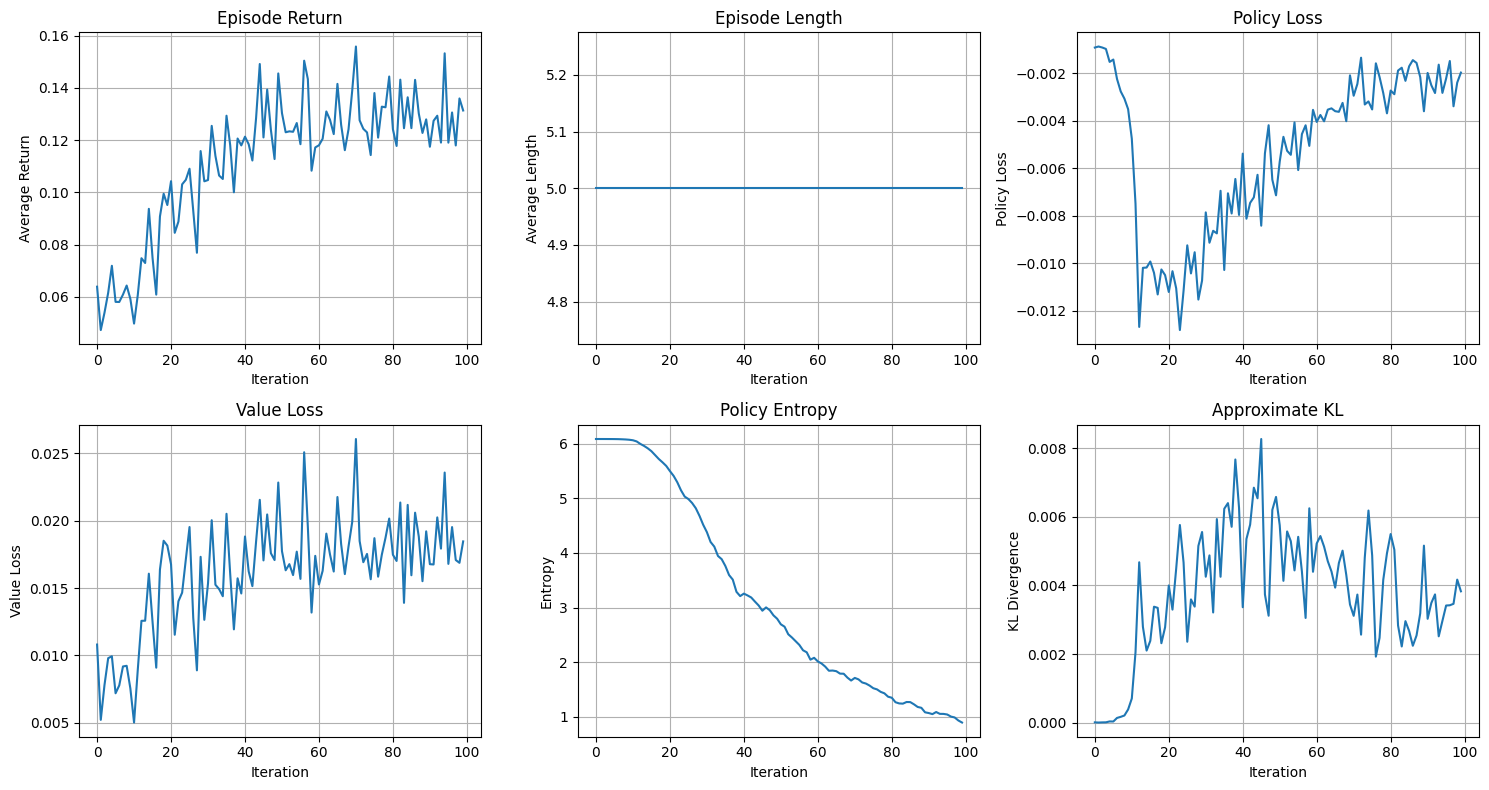

In [28]:
# Plot training curves
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Average return
axes[0, 0].plot(metrics['iteration'], metrics['avg_return'])
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Average Return')
axes[0, 0].set_title('Episode Return')
axes[0, 0].grid(True)

# Episode length
axes[0, 1].plot(metrics['iteration'], metrics['avg_episode_length'])
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Average Length')
axes[0, 1].set_title('Episode Length')
axes[0, 1].grid(True)

# Policy loss
axes[0, 2].plot(metrics['iteration'], metrics['policy_loss'])
axes[0, 2].set_xlabel('Iteration')
axes[0, 2].set_ylabel('Policy Loss')
axes[0, 2].set_title('Policy Loss')
axes[0, 2].grid(True)

# Value loss
axes[1, 0].plot(metrics['iteration'], metrics['value_loss'])
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('Value Loss')
axes[1, 0].set_title('Value Loss')
axes[1, 0].grid(True)

# Entropy
axes[1, 1].plot(metrics['iteration'], metrics['entropy'])
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('Entropy')
axes[1, 1].set_title('Policy Entropy')
axes[1, 1].grid(True)

# Approx KL
axes[1, 2].plot(metrics['iteration'], metrics['approx_kl'])
axes[1, 2].set_xlabel('Iteration')
axes[1, 2].set_ylabel('KL Divergence')
axes[1, 2].set_title('Approximate KL')
axes[1, 2].grid(True)

plt.tight_layout()
plt.show()

In [22]:
reward_fn = get_reward_fn(entropy_reward, negative_reward=False, num_steps=hyperparams["env_params"]["model_steps"])


[0]
[1]
[0]
[1]
[1]
[1]
6


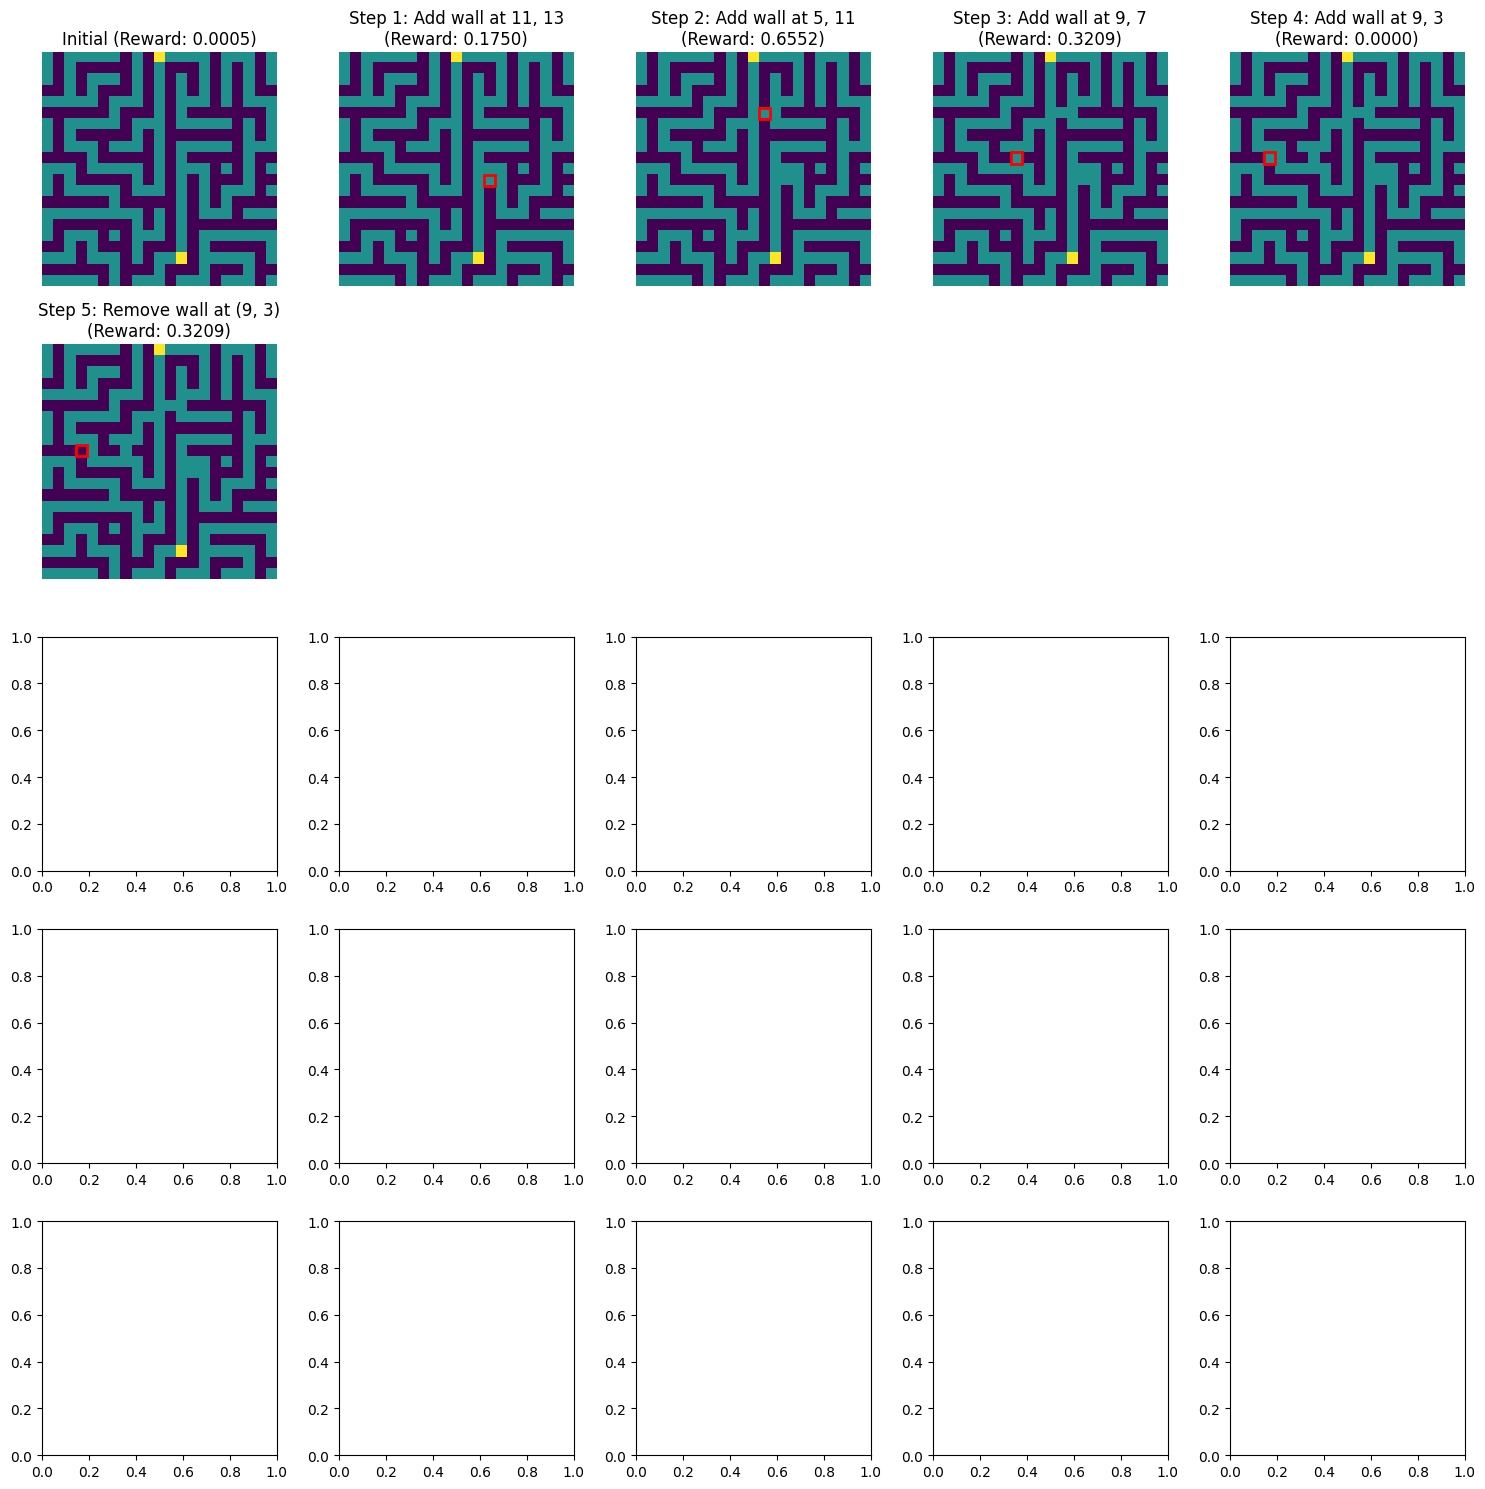

Episode finished in 5 steps
Actions: 1 walls added, 4 walls removed


In [32]:
# Visualize trained agent editing a maze
from textwrap import wrap

def visualize_episode(env, policy, maze, reward_fn, device='cuda', max_steps=50, grid_size=21, title_width=30):
    """
    Visualize an episode of the trained agent editing a maze.
    """
    policy.eval()
    obs, mask = env.reset(maze)
    frames = [obs.clone()]
    actions_taken = []
    rewards = []
    
    reward = reward_fn(obs)
    rewards.append(reward.item())

    for step in range(max_steps):
        with torch.no_grad():
            logits, value = policy(
                obs.unsqueeze(0).to(device),
                mask.unsqueeze(0).to(device)
            )
            dist = Categorical(logits=logits)
            action = dist.sample()
        
        actions_taken.append(action.item())
        obs, done, is_end, mask = env.step(action.item())
        frames.append(obs.clone())

        reward = reward_fn(obs)
        rewards.append(reward.item())
        
        if done:
            break
    
    policy.train()
    
    # Plot trajectory
    num_frames = len(frames) # Show first 10 frames
    print(num_frames)
    fig, axes = plt.subplots(5, 5, figsize=(15, 15))
    axes = axes.flatten()
    
    for i in range(num_frames):
        frame = frames[i]
        
        edited_cell = None
        # Prepare human-friendly, wrapped titles
        if i == 0:
            title_str = 'Initial'
        elif i < len(actions_taken) + 1:
            action = actions_taken[i-1]
            if action == env.action_dim - 1:
                title_str = f'Step {i}: END'
            elif action < grid_size * grid_size:
                edited_cell = (action // grid_size, action % grid_size)
                title_str = f'Step {i}: Remove wall at {edited_cell}'
            else:
                edited_cell = (action - grid_size * grid_size) // grid_size, (action - grid_size * grid_size) % grid_size
                title_str = f'Step {i}: Add wall at {(action - grid_size * grid_size) // grid_size}, {(action - grid_size * grid_size) % grid_size} '
        else:
            title_str = ""
        
        title_str = title_str + f' (Reward: {rewards[i]:.4f})'

        axes[i].set_title("\n".join(wrap(title_str, width=title_width)))
        axes[i].axis('off')

        display = frame[0].numpy() + 2 * frame[1].numpy()
        axes[i].imshow(display, cmap='viridis', vmin=0, vmax=2)
        if edited_cell:
            rect = Rectangle((edited_cell[1] - 0.5, edited_cell[0] - 0.5), 1, 1, 
                             linewidth=2, edgecolor='red', facecolor='none')
            axes[i].add_patch(rect)
    
    # Hide unused subplots
    for i in range(num_frames, 10):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Episode finished in {len(actions_taken)} steps")
    print(f"Actions: {sum(1 for a in actions_taken if a < grid_size * grid_size)} walls added, "
          f"{sum(1 for a in actions_taken if grid_size * grid_size <= a < grid_size * grid_size * 2)} walls removed")

iterator = iter(maze_loader)
maze = next(iterator)[0]
walls = maze[:, 0, :, :]
starts = maze[:, -1, :, :]
maze = torch.stack([walls, starts], dim=1)
maze = maze[:, :, ::2, ::2]
maze = maze[0, :, 2:-1, 2:-1]

# Run visualization
grid_size = hyperparams["env_params"]["grid_size"]
visualize_episode(env, policy, maze, reward_fn, device=device, grid_size=grid_size)

In [33]:
# Save trained model
hyperparams["notes"] = ""
torch.save({
    'policy_state_dict': policy.state_dict(),
    'training_metrics': metrics,
    'params': hyperparams
}, 'ppo_maze_editor_entropy_increaser_1_negative.pth')

In [99]:
# Load trained model (optional)
checkpoint = torch.load('ppo_maze_editor_good_entropy_decreaser_1.pth')
policy.load_state_dict(checkpoint['policy_state_dict'])
metrics = checkpoint['training_metrics']
params = checkpoint['params']
print("Model loaded successfully")

print(params)

Model loaded successfully
{'env_params': {'grid_size': 21, 'max_steps': 5, 'end_token': True, 'step_penalty': 0.0001, 'dense_reward': True, 'end_bonus': 0.04}, 'policy_params': {'hidden_dim': 128}, 'training_params': {'lr': 2e-05, 'batch_size': 512, 'num_epochs': 8, 'minibatch_size': 256, 'num_iterations': 100, 'gamma': 0.99, 'gae_lambda': 0.97, 'clip_epsilon': 0.2, 'value_coef': 0.8, 'entropy_coef': 0.005, 'max_grad_norm': 0.5}}


/tmp/ipykernel_2255274/2943123298.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('ppo_maze_editor_good_entropy_decreaser_1.pth')


In [ ]:
#models: 
# ppo_maze_editor_good_entropy_decreaser_1
# ppo_maze_editor_mid_entropy_increaser_1_positive.pth - worth checking out
# ppo_maze_editor_entropy_increaser_1_negative.pth - def worth checking out, weird though it changes the decision a lot